In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
# 학습 데이터 로드
df = pd.read_csv('/content/drive/MyDrive/IBA/titanic_train.csv')


Mounted at /content/drive


In [2]:
# 피쳐 정보 요약
# PassengerID : 탑승자 데이터 일련번호
# ★survived : 생존 여부 / 0 = 사망, 1 = 생존★
# pclass : 티켓의 선실 등급, 1 = 일등석, 2 = 이등석, 3 = 삼등석
# sex : 탑승자 성별
# name : 탑승자 이름
# age : 탑승자 나이
# sibsp : 같이 탑승한 형제자매 또는 배우자 인원수
# parch : 같이 탑승한 부모님 또는 어린이 인원수
# ticket : 티켓 번호
# fare : 요금
# cabin : 선실 번호
# embarked : 중간 정착 항구 C = Cherbourg, Q = Queenstown, S = Southampton

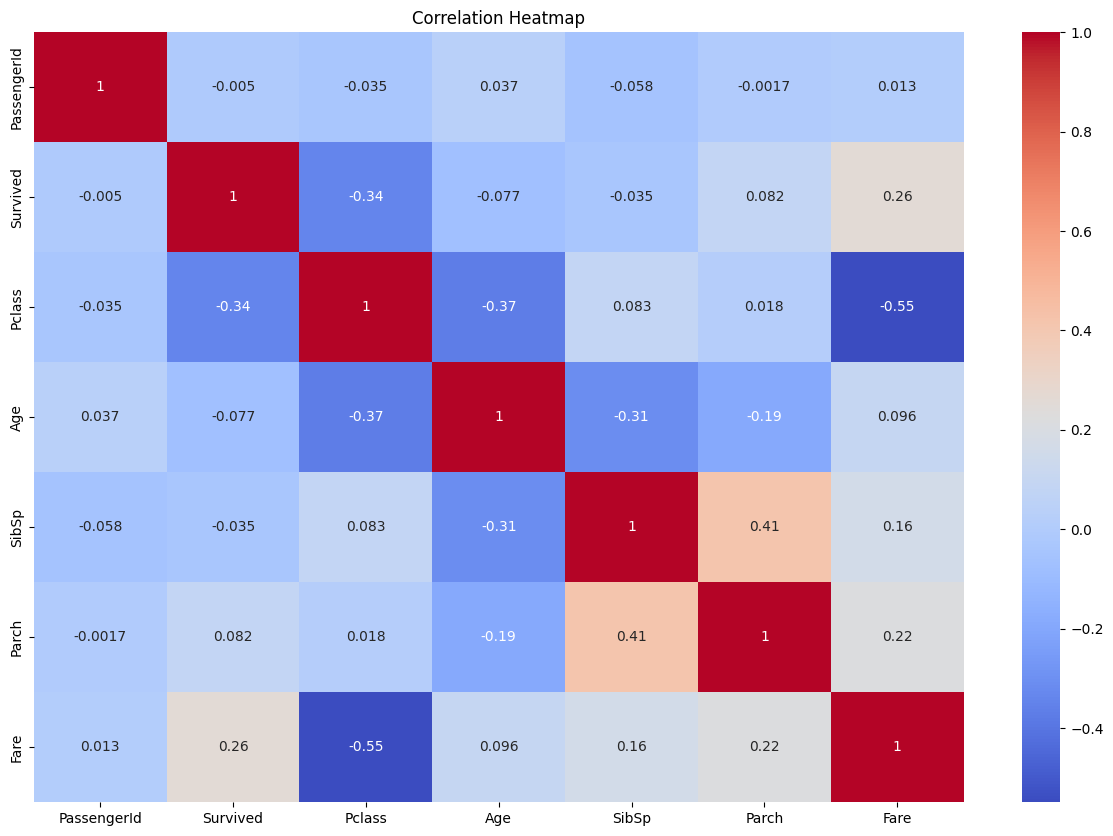

In [3]:
# 코드 작성

import seaborn as sns

# 상관관계 행렬 계산
corr_matrix = df.select_dtypes(include=['number']).corr()

# 상관관계 히트맵(heatmap) 그리기
plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# sns.heatmap에서의 annot은 히트맵 각 셀의 상관 계수 값 표시 여부 / cmap은 scatter과 동일한 색상맵 선택


       성별     생존율(%)
0  female  74.203822
1    male  18.890815


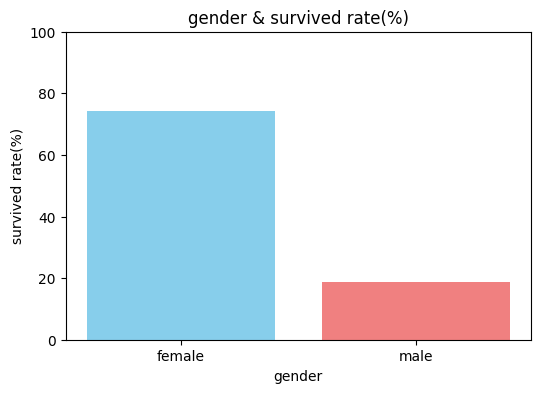

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

survival_rate = df.groupby("Sex")["Survived"].mean() * 100

survival_rate_df = survival_rate.reset_index()
survival_rate_df.columns = ["성별", "생존율(%)"]

print(survival_rate_df)

# 막대그래프
plt.figure(figsize=(6,4))
plt.bar(survival_rate_df["성별"], survival_rate_df["생존율(%)"], color=["skyblue", "lightcoral"])
plt.title("gender & survived rate(%)")
plt.ylabel("survived rate(%)")
plt.xlabel("gender")
plt.ylim(0,100)
plt.show()


   좌석등급     생존율(%)
0     1  62.962963
1     2  47.282609
2     3  24.236253


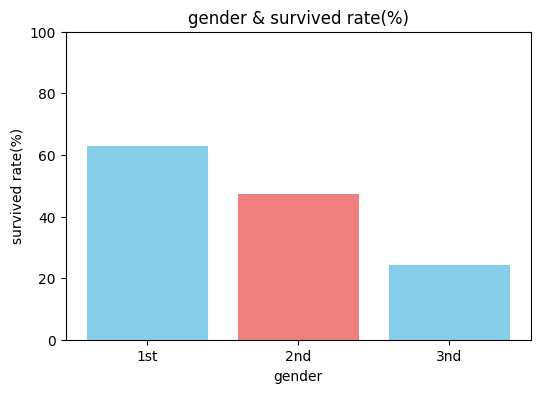

In [5]:
#df["Pclass"] = df["Pclass"].astype("category")


survival_rate = df.groupby("Pclass")["Survived"].mean() * 100

survival_rate_df = survival_rate.reset_index()
survival_rate_df.columns = ["좌석등급", "생존율(%)"]

print(survival_rate_df)

# 막대그래프
plt.figure(figsize=(6,4))
plt.bar(survival_rate_df["좌석등급"], survival_rate_df["생존율(%)"], color=["skyblue", "lightcoral"])
plt.xticks([1, 2, 3], ["1st", "2nd", "3nd"])
plt.title("gender & survived rate(%)")
plt.ylabel("survived rate(%)")
plt.xlabel("gender")
plt.ylim(0,100)
plt.show()

Sex        female       male
Pclass                      
1       96.808511  36.885246
2       92.105263  15.740741
3       50.000000  13.544669


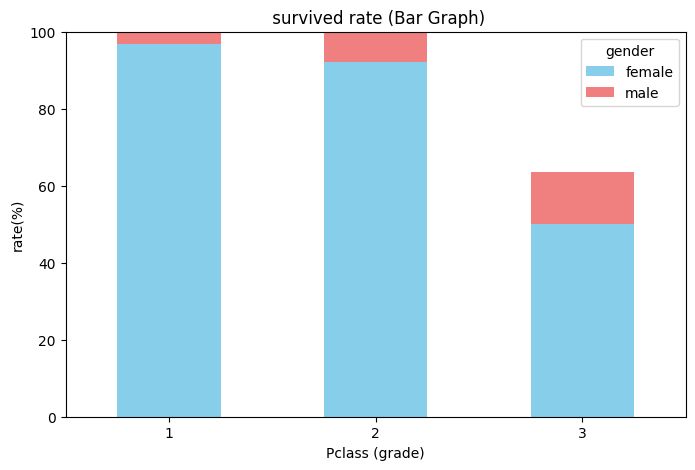

In [6]:

# Pclass(등급)별 + 성별 생존율 계산 (%)
pclass_sex_survival = df.groupby(["Pclass", "Sex"])["Survived"].mean().unstack() * 100

print(pclass_sex_survival)


pclass_sex_survival.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    color=["skyblue", "lightcoral"]
)

plt.title(" survived rate (Bar Graph)")
plt.ylabel("rate(%)")
plt.xlabel("Pclass (grade)")
plt.ylim(0,100)
plt.xticks(rotation=0)
plt.legend(title="gender")

plt.show()


In [ ]:
# 주제 : 남성과 여성의 객실 등급 간 생존률 비교

# 그래프 선택 : 히스토그램, 객실별 생존자를 쉽게 구분해서 나타낼 수 있고
# 색상 변화를 통해 성별을 구분하기 쉽기 때문에 선정하게 되었다.


# 결과 해석:
# x축은 객실은 등급, y축은 생존률, 여성은 하늘색, 남성은 빨간색으로 표현했다.

# 등급이 높을수록 생존률이 높았고 여성의 생존률이 남성의 생존률보다 높다

# 객실 등급이 높을수록 생존자의 남녀비율에서 여자의 비율이 더 높게 나타났다.